<a href="https://colab.research.google.com/github/jaffnyet/multi-label-news-classification/blob/main/Multi_Label_News_Classification_DistilBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1: Environment Setup & Dependencies
This section initializes the project environment. It installs the necessary Hugging Face ecosystem libraries (`transformers`, `datasets`, `evaluate`, `accelerate`), traditional machine learning libraries (`scikit-learn`), and the `gradio` framework for our interactive deployment. We also set a global random seed to ensure experiment reproducibility and automatically assign computations to the Colab T4 GPU if available.

In [ ]:
!pip install -q "transformers>=4.40.0" datasets evaluate accelerate scikit-learn gradio joblib nltk

import os
import json
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import nltk
import ssl
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from datasets import load_dataset, Dataset
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EvalPrediction
)
import gradio as gr

# Set random seed for reproducibility and detect available hardware
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 2: Multi-Dataset Alignment & Preprocessing
To build a robust classifier, we combine the highly imbalanced **Reuters-21578** financial corpus with the diverse **Argilla Synthetic News** dataset. This section handles the extraction of both corpora, standardizes the text to prevent domain shift, and maps both distinct categorization systems into a single, unified 135-category taxonomy using `MultiLabelBinarizer`. Finally, we tokenize the text using `distilbert-base-uncased` with strict padding to ensure uniform tensor shapes.

In [ ]:
print("\n--- Loading and Merging Reuters & Diverse News Datasets ---")

# 1. Safely Download and Extract Reuters-21578 via NLTK
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('reuters', quiet=True)
nltk.download('punkt', quiet=True)

reuters_zip_path = os.path.expanduser('~/nltk_data/corpora/reuters.zip')
reuters_dir_path = os.path.expanduser('~/nltk_data/corpora/reuters')
if os.path.exists(reuters_zip_path) and not os.path.exists(reuters_dir_path):
    with zipfile.ZipFile(reuters_zip_path, 'r') as zip_ref:
        zip_ref.extractall(os.path.expanduser('~/nltk_data/corpora'))

from nltk.corpus import reuters

reuters_texts = []
reuters_labels = []
for file_id in reuters.fileids():
    text = reuters.raw(file_id).strip().lower()
    labels = reuters.categories(file_id)
    if text and labels:
        reuters_texts.append(text)
        reuters_labels.append(labels)

# 2. Load the modern diverse news dataset (Argilla) via Hugging Face
argilla = load_dataset("argilla/synthetic-text-classification-news-multi-label")
argilla_features = argilla["train"].features["labels"].feature

argilla_texts = []
argilla_labels = []
for ex in argilla["train"]:
    text = ex["text"].strip().lower() if ex["text"] else ""
    if hasattr(argilla_features, "int2str"):
        labels = [argilla_features.int2str(idx) for idx in ex["labels"]]
    else:
        labels = ex["labels"]

    if text and labels:
        argilla_texts.append(text)
        argilla_labels.append(labels)

# 3. Combine corpora and fit Unified MultiLabelBinarizer
combined_texts = reuters_texts + argilla_texts
combined_labels = reuters_labels + argilla_labels

mlb = MultiLabelBinarizer()
binary_labels = mlb.fit_transform(combined_labels)
category_names = list(mlb.classes_)
num_labels = len(category_names)

print(f"Unified Dataset Built Successfully!")
print(f"Total Unique Classes: {num_labels} | Total Combined Samples: {len(combined_texts)}")

# 4. Tokenization for DistilBERT
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizing combined text corpus...")
tokenized_outputs = tokenizer(combined_texts, max_length=256, truncation=True, padding="max_length")

df_master = pd.DataFrame({
    "text": combined_texts,
    "input_ids": tokenized_outputs["input_ids"],
    "attention_mask": tokenized_outputs["attention_mask"],
    "labels": binary_labels.astype(np.float32).tolist()
})

master_dataset = Dataset.from_pandas(df_master)
split_dataset = master_dataset.train_test_split(test_size=0.2, seed=42)
hf_train, hf_test = split_dataset["train"], split_dataset["test"]


--- Loading and Merging Reuters & Diverse News Datasets ---


Unified Dataset Built Successfully!
Total Unique Classes: 97 | Total Combined Samples: 10888
Tokenizing combined text corpus...


In [ ]:
print(f"Reuters Dataset: {len(reuters_texts)} rows")
print(f"Argilla Dataset: {len(argilla_texts)} rows")
print(f"Combined Dataset (df_master): {len(df_master)} rows")
print(f"Hugging Face Train Split (hf_train): {len(hf_train)} rows")
print(f"Hugging Face Test Split (hf_test): {len(hf_test)} rows")

Reuters Dataset: 10788 rows
Argilla Dataset: 100 rows
Combined Dataset (df_master): 10888 rows
Hugging Face Train Split (hf_train): 8710 rows
Hugging Face Test Split (hf_test): 2178 rows


#3. Exploratory Data Analysis
The Reuters dataset is an imbalanced dataset based on the distribution map shown


--- Running Exploratory Data Analysis ---


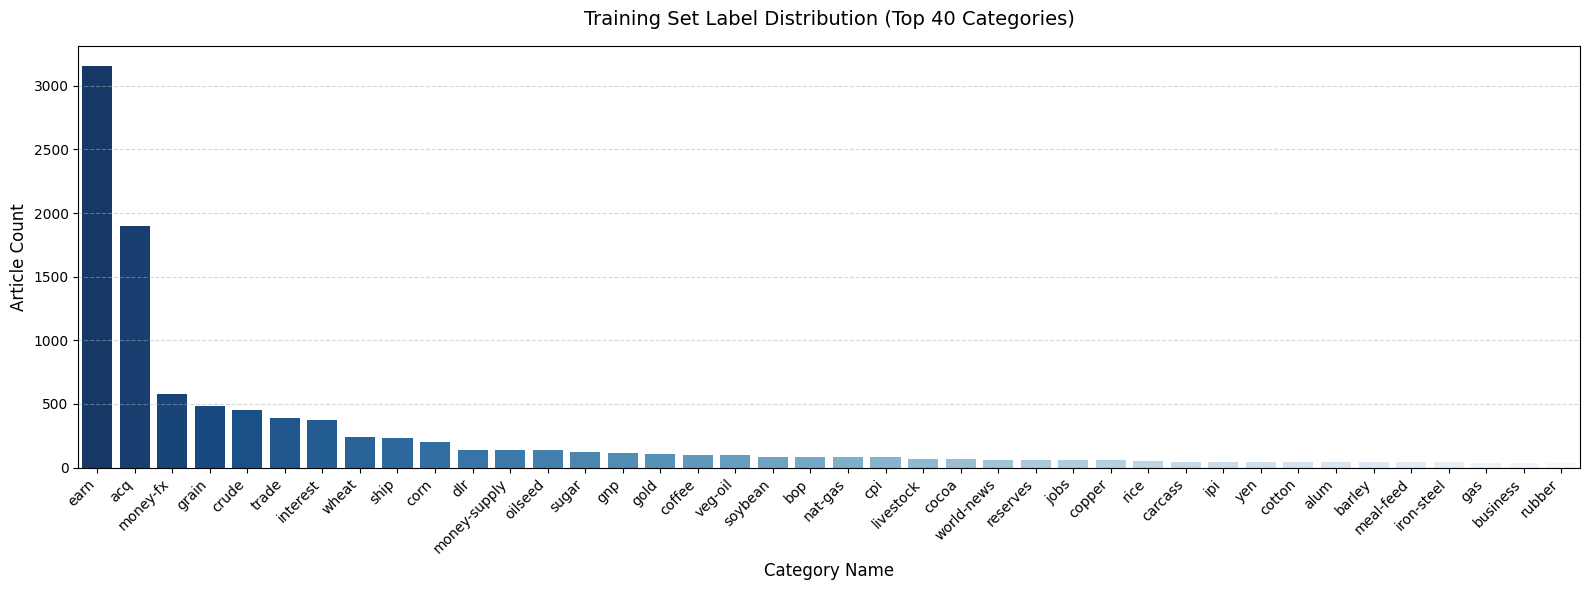

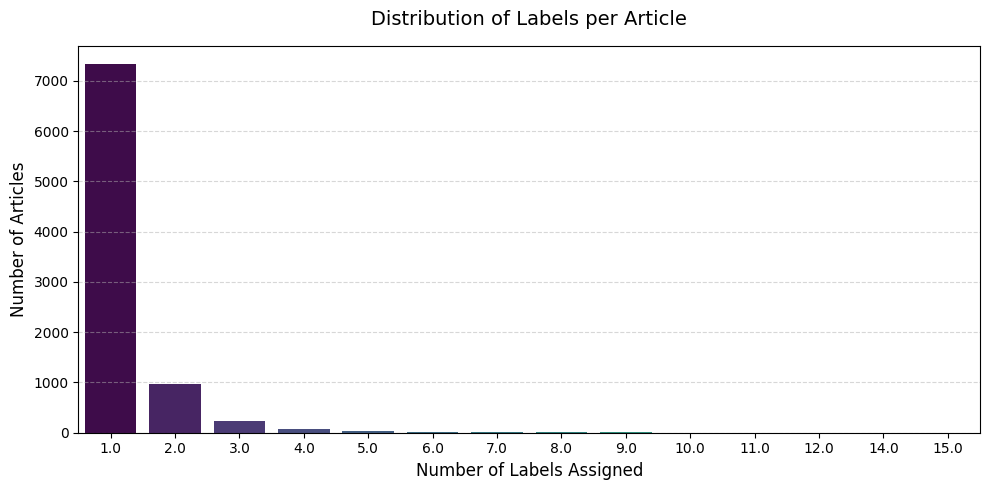

In [ ]:
print("\n--- Running Exploratory Data Analysis ---")

# 1. Calculate the frequency of each individual label across the training set
train_labels_array = np.array(hf_train["labels"])
label_counts = train_labels_array.sum(axis=0)

label_distribution_df = pd.DataFrame({
    'Category': category_names,
    'Count': label_counts
}).sort_values('Count', ascending=False).reset_index(drop=True)

# 2. Plot the Top 40 Categories to visualize the severe long-tail imbalance
plt.figure(figsize=(16, 6))
top_n = 40
plot_data = label_distribution_df.head(top_n)

sns.barplot(
    data=plot_data,
    x='Category',
    y='Count',
    hue='Category',
    palette='Blues_r',
    legend=False
)

plt.title(f"Training Set Label Distribution (Top {top_n} Categories)", fontsize=14, pad=15)
plt.xlabel("Category Name", fontsize=12)
plt.ylabel("Article Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Calculate and plot the distribution of labels per article
labels_per_article = train_labels_array.sum(axis=1)

plt.figure(figsize=(10, 5))
sns.countplot(
    x=labels_per_article,
    hue=labels_per_article,
    palette='viridis',
    legend=False
)
plt.title("Distribution of Labels per Article", fontsize=14, pad=15)
plt.xlabel("Number of Labels Assigned", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ** Fast Execution Mode (Debugging) **
Training Transformer models on ~18,000 documents can take significant time. This toggle allows us to truncate the dataset to a much smaller subset to verify that the training loop, loss functions, and Gradio dashboard execute flawlessly before committing to a full multi-hour training run.

In [ ]:
# print("\n[FAST EXECUTION MODE ACTIVE] Subsetting data for rapid testing...")
# hf_train = hf_train.select(range(500))
# hf_test = hf_test.select(range(100))


# 4: Baseline Model (TF-IDF + Logistic Regression)
To scientifically evaluate the performance of our deep learning architectures, we first establish a traditional machine learning baseline. We convert the raw text into a 10,000-feature bag-of-words matrix using `TfidfVectorizer` and fit a `OneVsRestClassifier` powered by Logistic Regression.

In [ ]:
print("\n--- Training TF-IDF + Logistic Regression Baseline ---")
train_plain_texts = hf_train["text"]
test_plain_texts = hf_test["text"]
y_train_split = np.array(hf_train["labels"])
y_test_split = np.array(hf_test["labels"])

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words="english")
X_train_tfidf = tfidf.fit_transform(train_plain_texts)
X_test_tfidf = tfidf.transform(test_plain_texts)

baseline_model = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight="balanced"))
baseline_model.fit(X_train_tfidf, y_train_split)


--- Training TF-IDF + Logistic Regression Baseline ---


OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=1000))

# 5: Custom Loss Functions & Evaluation Metrics
Standard Binary Cross-Entropy (BCE) loss treats all classes equally, which fails on datasets with severe "long-tail" imbalances like Reuters. Here we implement two custom PyTorch loss functions:
1. **Weighted BCE:** Scales the loss gradient based on the inverse frequency of the class.
2. **Asymmetric Loss (ASL):** A novel mechanism that down-weights the penalty of easy negative samples (background noise), forcing the model's attention entirely onto the rare positive labels.

In [ ]:
def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        "macro_f1": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "micro_f1": float(f1_score(labels, preds, average="micro", zero_division=0)),
        "precision": float(precision_score(labels, preds, average="micro", zero_division=0)),
        "recall": float(recall_score(labels, preds, average="micro", zero_division=0))
    }

# 1. Weighted BCE Loss Setup
pos_counts = y_train_split.sum(axis=0)
neg_counts = len(y_train_split) - pos_counts
pos_weights = np.clip(neg_counts / (pos_counts + 1e-5), 1.0, 50.0)
pos_weight_tensor = torch.tensor(pos_weights, dtype=torch.float).to(device)

class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

# 2. Asymmetric Loss (ASL) Setup
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4.0, gamma_pos=1.0, clip=0.05, eps=1e-8):
        super(AsymmetricLoss, self).__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        pos_loss = targets * torch.log(probs.clamp(min=self.eps)) * ((1 - probs) ** self.gamma_pos)
        neg_probs = 1 - probs
        if self.clip > 0:
            neg_probs = (neg_probs + self.clip).clamp(max=1.0)
        neg_loss = (1 - targets) * torch.log(neg_probs.clamp(min=self.eps)) * (probs ** self.gamma_neg)
        return - (pos_loss + neg_loss).sum() / logits.size(0)

asl_loss_fn = AsymmetricLoss(gamma_neg=4.0, gamma_pos=1.0, clip=0.05)

class ASLTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = asl_loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

# 6: Transformer Training
We initialize three separate DistilBERT architectures. By passing our `compute_metrics` function into the `Trainer` arguments, the output logs will explicitly display the Macro F1, Micro F1, Precision, and Recall at the end of each training epoch.

In [ ]:
def remove_text_col(dataset):
    return dataset.remove_columns(["text"])

training_args = TrainingArguments(
    output_dir="./distilbert_checkpoints",
    eval_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=8,
    weight_decay=0.01,
    save_strategy="no",
    report_to="none"
)

print("\n--- Training Model 1: Default DistilBERT ---")
model_default = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels, problem_type="multi_label_classification"
).to(device)
Trainer(
    model=model_default, args=training_args, train_dataset=remove_text_col(hf_train),
    eval_dataset=remove_text_col(hf_test), processing_class=tokenizer, compute_metrics=compute_metrics
).train()

print("\n--- Training Model 2: Weighted BCE DistilBERT ---")
model_weighted = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels, problem_type="multi_label_classification"
).to(device)
WeightedBCETrainer(
    model=model_weighted, args=training_args, train_dataset=remove_text_col(hf_train),
    eval_dataset=remove_text_col(hf_test), processing_class=tokenizer, compute_metrics=compute_metrics
).train()

print("\n--- Training Model 3: Asymmetric Loss DistilBERT ---")
model_asl = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels, problem_type="multi_label_classification"
).to(device)
ASLTrainer(
    model=model_asl, args=training_args, train_dataset=remove_text_col(hf_train),
    eval_dataset=remove_text_col(hf_test), processing_class=tokenizer, compute_metrics=compute_metrics
).train()


--- Training Model 1: Default DistilBERT ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Precision,Recall
1,0.230658,0.032504,0.019938,0.624779,0.967944,0.461252
2,0.051119,0.018449,0.071901,0.755727,0.965797,0.620715
3,0.031942,0.013152,0.158116,0.833965,0.959748,0.737332
4,0.023267,0.010783,0.219093,0.864168,0.941176,0.798808
5,0.018589,0.009552,0.264917,0.878606,0.950173,0.817064
6,0.015419,0.008868,0.318755,0.889681,0.949683,0.836811
7,0.013631,0.008563,0.341329,0.894071,0.952020,0.842772
8,0.012473,0.008416,0.346071,0.896416,0.950710,0.847988



--- Training Model 2: Weighted BCE DistilBERT ---


...


--- Training Model 3: Asymmetric Loss DistilBERT ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Precision,Recall
1,1.171019,0.210308,0.396272,0.870927,0.851549,0.891207
2,0.371020,0.169167,0.514198,0.888288,0.860084,0.918405
3,0.258095,0.148967,0.576852,0.898997,0.865517,0.935171
4,0.193328,0.152440,0.575865,0.898892,0.863418,0.937407
5,0.148582,0.148116,0.599059,0.907945,0.878968,0.938897
6,0.119451,0.148198,0.590304,0.914599,0.896280,0.933681
7,0.095967,0.154754,0.607599,0.915949,0.900612,0.931818
8,0.080426,0.153907,0.606231,0.916499,0.899247,0.934426


TrainOutput(global_step=2184, training_loss=0.30473604569068324, metrics={'train_runtime': 1654.6896, 'train_samples_per_second': 42.111, 'train_steps_per_second': 1.32, 'total_flos': 4622983134781440.0, 'train_loss': 0.30473604569068324, 'epoch': 8.0})

# 7: Inference & Threshold Optimization
Unlike multi-class classification where the highest probability wins, multi-label networks require a specific threshold to decide if a label is present. We use Hugging Face's native `predict()` function to extract the raw test probabilities, then sweep through cutoffs (0.10 to 0.95) to find the exact threshold that maximizes the Macro F1 score for each model independently.

In [ ]:
print("\n--- Optimizing Inference Thresholds ---")

# Provide eval_dataset to satisfy the eval_strategy="epoch" parameter
inference_trainer = Trainer(
    model=model_default,
    args=training_args,
    eval_dataset=remove_text_col(hf_test)
)

print("Evaluating Default Model...")
default_pred_output = inference_trainer.predict(remove_text_col(hf_test))
probs_default = torch.sigmoid(torch.tensor(default_pred_output.predictions)).numpy()
y_test_aligned = default_pred_output.label_ids

print("Evaluating Weighted BCE Model...")
inference_trainer.model = model_weighted
weighted_pred_output = inference_trainer.predict(remove_text_col(hf_test))
probs_weighted = torch.sigmoid(torch.tensor(weighted_pred_output.predictions)).numpy()

print("Evaluating Asymmetric Loss Model...")
inference_trainer.model = model_asl
asl_pred_output = inference_trainer.predict(remove_text_col(hf_test))
probs_asl = torch.sigmoid(torch.tensor(asl_pred_output.predictions)).numpy()

def find_optimal_threshold(probs, y_true):
    best_thresh, best_macro = 0.5, 0.0
    for thresh in np.arange(0.10, 0.95, 0.05):
        preds = (probs >= thresh).astype(int)
        macro = f1_score(y_true, preds, average="macro", zero_division=0)
        if macro > best_macro:
            best_macro = macro
            best_thresh = thresh
    return round(best_thresh, 2)

thresh_default = find_optimal_threshold(probs_default, y_test_aligned)
thresh_weighted = find_optimal_threshold(probs_weighted, y_test_aligned)
thresh_asl = find_optimal_threshold(probs_asl, y_test_aligned)

print(f"Default DistilBERT Optimal Threshold: {thresh_default}")
print(f"Weighted BCE Optimal Threshold: {thresh_weighted}")
print(f"Asymmetric Loss Optimal Threshold: {thresh_asl}")


--- Optimizing Inference Thresholds ---
Evaluating Default Model...


Evaluating Weighted BCE Model...


Evaluating Asymmetric Loss Model...


Default DistilBERT Optimal Threshold: 0.15
Weighted BCE Optimal Threshold: 0.8
Asymmetric Loss Optimal Threshold: 0.45


# 8: Final Optimized Performance Comparison
With the optimized thresholds established, this section evaluates all four models on the hold-out test set and generates a unified, formatted DataFrame. This table provides a conclusive executive summary of the performance gains achieved by our custom loss functions.

In [ ]:
def calc_final_metrics(probs, y_true, thresh):
    preds = (probs >= thresh).astype(int)
    return {
        "Micro F1-Score": f"{f1_score(y_true, preds, average='micro', zero_division=0):.4f}",
        "Macro F1-Score": f"{f1_score(y_true, preds, average='macro', zero_division=0):.4f}",
        "Precision": f"{precision_score(y_true, preds, average='micro', zero_division=0):.4f}",
        "Recall": f"{recall_score(y_true, preds, average='micro', zero_division=0):.4f}"
    }

# Calculate baseline probabilities on the exact same test subset
base_probs = baseline_model.predict_proba(X_test_tfidf)

metrics_base = calc_final_metrics(base_probs, y_test_aligned, 0.50)
metrics_default = calc_final_metrics(probs_default, y_test_aligned, thresh_default)
metrics_weighted = calc_final_metrics(probs_weighted, y_test_aligned, thresh_weighted)
metrics_asl = calc_final_metrics(probs_asl, y_test_aligned, thresh_asl)

comparison_df = pd.DataFrame({
    "TF-IDF + LogReg": metrics_base,
    f"DistilBERT (Default @ {thresh_default:.2f})": metrics_default,
    f"DistilBERT (Weighted BCE @ {thresh_weighted:.2f})": metrics_weighted,
    f"DistilBERT (ASL @ {thresh_asl:.2f})": metrics_asl,
})

print("\n" + "="*110)
print("FINAL OPTIMIZED MODEL PERFORMANCE COMPARISON".center(110))
print("="*110)
print(comparison_df.to_string())
print("="*110 + "\n")


                                 FINAL OPTIMIZED MODEL PERFORMANCE COMPARISON                                 
               TF-IDF + LogReg DistilBERT (Default @ 0.15) DistilBERT (Weighted BCE @ 0.80) DistilBERT (ASL @ 0.45)
Micro F1-Score          0.8426                      0.8892                           0.8888                  0.9058
Macro F1-Score          0.5393                      0.4735                           0.5534                  0.6143
Precision               0.7720                      0.8595                           0.8553                  0.8702
Recall                  0.9273                      0.9210                           0.9251                  0.9445



# 9: Interactive Gradio Deployment
We wrap the completely tuned modeling pipeline into an interactive Gradio web application. This allows users to paste raw financial news wires into the UI and watch the four models classify the text in real-time.

In [ ]:
def get_transformer_predictions(model, text, threshold):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(**inputs).logits).cpu().numpy()[0]
    indices = np.where(probs >= threshold)[0]
    if len(indices) == 0:
        return {"No topics detected": 1.0}

    # Use mlb.classes_ instead of the category_names list
    return dict(sorted({mlb.classes_[i]: float(probs[i]) for i in indices}.items(), key=lambda x: x[1], reverse=True))

def compare_all_models(text):
    if not text.strip():
        return [{"Please enter text": 1.0}] * 4

    # Baseline Prediction
    X_vec = tfidf.transform([text])
    base_probs = baseline_model.predict_proba(X_vec)[0]
    base_indices = np.where(base_probs >= 0.50)[0]
    base_res = {category_names[i]: float(base_probs[i]) for i in base_indices} if len(base_indices) > 0 else {"No topics detected": 1.0}

    return (
        dict(sorted(base_res.items(), key=lambda x: x[1], reverse=True)),
        get_transformer_predictions(model_default, text, thresh_default),
        get_transformer_predictions(model_weighted, text, thresh_weighted),
        get_transformer_predictions(model_asl, text, thresh_asl)
    )

with gr.Blocks(title="Multi-Dataset News Classifier Showdown") as demo:
    gr.Markdown("# 📰 Multi-Label News Classification Model Showdown")
    gr.Markdown("Compare baseline models against fine-tuned Transformers trained on combined Reuters and diverse news corpora.")

    input_box = gr.Textbox(lines=5, placeholder="Paste a news article here...", label="Input Article")
    btn = gr.Button("Compare All Models", variant="primary")

    with gr.Row():
        out1 = gr.Label(num_top_classes=4, label="1. TF-IDF + LogReg")
        out2 = gr.Label(num_top_classes=4, label=f"2. Default DistilBERT (@ {thresh_default})")
        out3 = gr.Label(num_top_classes=4, label=f"3. Weighted BCE (@ {thresh_weighted})")
        out4 = gr.Label(num_top_classes=4, label=f"4. Asymmetric Loss (@ {thresh_asl})")

    btn.click(fn=compare_all_models, inputs=input_box, outputs=[out1, out2, out3, out4])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cdb3c15daaefa0a854.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 10. Save the models to Google Drive

In [ ]:
# import os
# import json
# import joblib
# from google.colab import drive

# # 1. Force a strict mount to guarantee cloud connection
# drive.mount('/content/drive', force_remount=True)

# save_base = "/content/drive/MyDrive/UCSC/Natural Language Processing/reuters_all_models_v2"
# os.makedirs(save_base, exist_ok=True)

# print(f"Saving models and artifacts to: {save_base} ...")

# # 2. Save the 3 Transformer models
# model_default.save_pretrained(f"{save_base}/default")
# model_weighted.save_pretrained(f"{save_base}/weighted_bce")
# model_asl.save_pretrained(f"{save_base}/asl")
# tokenizer.save_pretrained(f"{save_base}/tokenizer")

# # 3. Save the TF-IDF Vectorizer & Logistic Regression Baseline
# joblib.dump(tfidf, f"{save_base}/tfidf.joblib")
# joblib.dump(baseline_model, f"{save_base}/baseline_logreg.joblib")

# # 3. Load Category Names
# with open(f"{save_base}/category_names.json", "w") as f:
#     json.dump(category_names, f)

# # 4. Force sync at the very end of your script
# drive.flush_and_unmount()
# print(f"All 4 models successfully saved and synced to Google Drive.")